# Full exact QuadraSHAP on TCGA LGG methylation

This follow-up measures the actual cost of an exact explanation with **396,065 active features**. It reuses the fitted ridge Cox coefficients, processed patient, and **four training-background patients** from [the original experiment](cox_survival.ipynb). No fitting or preprocessing is repeated, and no feature subset is substituted.

The purpose is to replace the earlier 128-node convergence reference with an algebraically exact rule for **the same first validation patient**. QuadraSHAP explains relative hazard $f(x)=\exp(x^\top\beta)$, using whole empirical background rows. A sufficient exact rule uses $\lceil396065/2\rceil=198033$ Gauss–Legendre nodes. Exactness refers to polynomial integration; float64 roundoff remains.

The computation runs on the local laptop. It processes blocks of ten quadrature nodes, retaining the previous memory-bounded implementation. Rule construction and integration are measured separately. Approximate timings are the saved medians from three cached-rule calls; the exact result is one new run. This is an extension of the fixed-model attribution benchmark, not a new predictive evaluation.

### Measured result on this laptop

| Stage | Time |
|---|---:|
| Construct 198,033-node rule | 513.85 s (8 min 34 s) |
| Integrate all 396,065 features and four backgrounds | 2,014.41 s (33 min 34 s) |
| Compute total | **2,528.27 s (42 min 8 s)** |

For the same patient and background, the saved 8-node approximation took **0.12195 s** and had relative L2 difference **6.96e-11** from the exact-rule result. The 16-node result took **0.19653 s**, with relative difference **4.62e-11**. The 8-node call was approximately 20,733 times faster than the cold exact computation, or 16,519 times faster than its integration stage alone. Approximate times are medians from the earlier three-repetition run; exact time is one new measurement.


In [1]:
from pathlib import Path
import sys, os, json, time
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path[:0] = [str(ROOT / "src"), str(ROOT)]
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/quadrashap-cox-matplotlib")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from threadpoolctl import threadpool_limits
from benchmarks.cox_exact_followup import run_exact_followup
THREAD_LIMIT = threadpool_limits(limits=4)
OUTPUT = ROOT / "benchmarks/results/cox_survival"
started = time.perf_counter()
print("Using saved model and patient: 396,065 active features; 198,033 nodes; 4 background rows.")

Using saved model and patient: 396,065 active features; 198,033 nodes; 4 background rows.


## Execute the full rule

The run first constructs the rule and checks its ordering, positive weights, and low-degree moments. These moment checks are numerical sanity checks, not a proof that all high-degree moments are exact in floating-point arithmetic. The rule is saved, then the full attribution call executes. Progress is written to `exact_progress.json` approximately every 30 seconds during integration.

`total_seconds` is rule-construction time plus the complete attribution-call time. Rule validation and intermediate disk writes are excluded from this compute total; `followup_wall_seconds` also records their overhead. Input hashes and software versions are saved in `exact_provenance.json`. The code refuses to overwrite an existing exact result.

In [2]:
exact_timing, comparison = run_exact_followup(ROOT)
display(pd.Series(exact_timing, name="Full exact glioma explanation"))
display(comparison[["m_q", "median_seconds", "relative_l2_error", "max_absolute_error",
                    "top20_overlap", "relative_efficiency_residual"]])

{"stage": "constructing_rule", "elapsed_seconds": 1.3339999895833898e-06, "updated_utc": "2026-09-13T08:58:12.956136+00:00", "nodes": 198033}


{"stage": "integrating", "elapsed_seconds": 513.9379609999996, "updated_utc": "2026-09-13T09:06:46.897107+00:00", "completed_fraction": 0, "rule_seconds": 513.8466941660004}


{"stage": "integrating", "elapsed_seconds": 543.9642417920004, "updated_utc": "2026-09-13T09:07:16.923565+00:00", "background_row": 0, "nodes_in_row": 10880, "completed_fraction": 0.013735084556614301, "rule_seconds": 513.8466941660004}


{"stage": "integrating", "elapsed_seconds": 573.9823804170001, "updated_utc": "2026-09-13T09:07:46.941879+00:00", "background_row": 0, "nodes_in_row": 22590, "completed_fraction": 0.028517974277014437, "rule_seconds": 513.8466941660004}


{"stage": "integrating", "elapsed_seconds": 603.9878514170005, "updated_utc": "2026-09-13T09:08:16.947531+00:00", "background_row": 0, "nodes_in_row": 34390, "completed_fraction": 0.04341448142481304, "rule_seconds": 513.8466941660004}


...

{"stage": "integrating", "elapsed_seconds": 2500.4485911250003, "updated_utc": "2026-09-13T09:39:53.393873+00:00", "background_row": 3, "nodes_in_row": 187010, "completed_fraction": 0.9860843899754081, "rule_seconds": 513.8466941660004}


{"stage": "integrating", "elapsed_seconds": 2528.354574709, "updated_utc": "2026-09-13T09:40:21.299891+00:00", "background_row": 3, "nodes_in_row": 198033, "completed_fraction": 1.0, "rule_seconds": 513.8466941660004}


{"stage": "complete", "elapsed_seconds": 2528.875558709, "updated_utc": "2026-09-13T09:40:21.820874+00:00", "completed_fraction": 1, "rule_seconds": 513.8466941660004, "integration_seconds": 2014.4128443749996, "total_seconds": 2528.2696637070007}


base_value                                                               0.034918
prediction                                                              12.071258
m_q                                                                        198033
exact_nodes                                                                198033
active_features                                                            396065
rule_seconds                                                           513.846694
integration_seconds                                                   2014.412844
total_seconds                                                         2528.269664
followup_wall_seconds                                                 2528.362109
patient                                                                         0
patient_id                                                           TCGA-CS-6665
repeats                                                                         1
background_size 

,m_q,median_seconds,relative_l2_error,max_absolute_error,top20_overlap,relative_efficiency_residual
0,1,0.046170,6.879501e-01,2.202536e-02,1.0,6.912766e-01
1,2,0.056083,1.233312e-01,3.975852e-03,1.0,1.257056e-01
2,4,0.075617,3.597599e-04,1.166322e-05,1.0,3.742297e-04
3,8,0.121946,6.961904e-11,2.254641e-12,1.0,2.519206e-11
4,16,0.196530,4.620932e-11,1.483161e-12,1.0,2.943118e-16
5,32,0.372133,4.621208e-11,1.483251e-12,1.0,3.090274e-15
6,64,0.703420,4.621841e-11,1.483459e-12,1.0,9.565134e-15
7,128,1.375421,4.619953e-11,1.482849e-12,1.0,9.565134e-15


## Compare with the exact result

The relative attribution error is $\|\hat\phi-\phi_{\rm exact}\|_2/\|\phi_{\rm exact}\|_2$. This checks all 396,065 feature contributions. The efficiency residual separately checks whether their sum plus the background mean recovers the patient's relative hazard; a small sum residual alone does not certify featurewise accuracy.

The figure below compares both cohorts' first validation patient against their respective full exact rules. Each cohort uses its own fitted model and background. The two exact runtimes were measured in separate runs on the same laptop; background size is four in both cases.

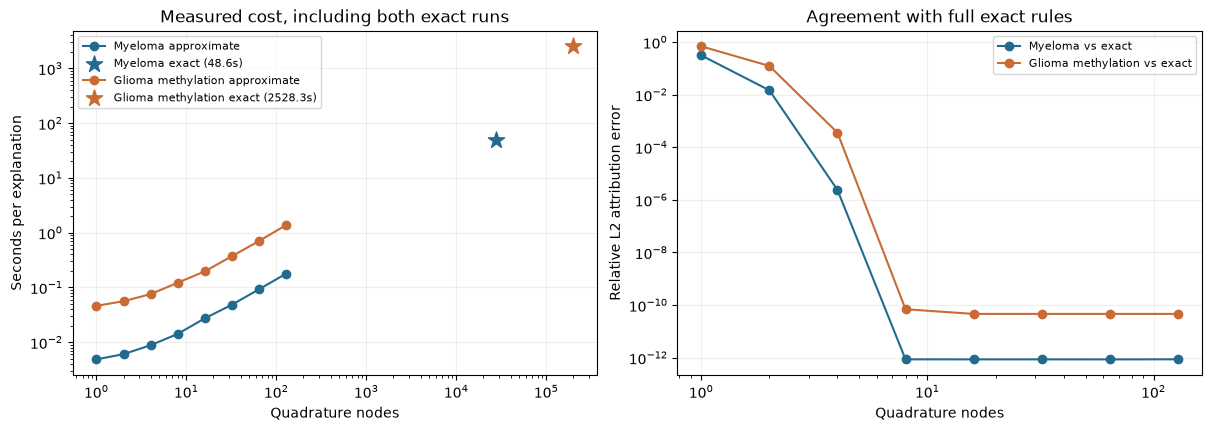

Follow-up notebook workflow: 2529.77 seconds


In [3]:
myeloma = pd.read_csv(OUTPUT / "gse24080/comparison.csv").query("patient == 0")
myeloma_exact = json.loads((OUTPUT / "gse24080/exact_timing.json").read_text())
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
for frame, exact, label, color in [(myeloma, myeloma_exact, "Myeloma", "#236B8E"),
                                   (comparison, exact_timing, "Glioma methylation", "#C86B35")]:
    axes[0].loglog(frame.m_q, frame.median_seconds, "o-", color=color, label=label + " approximate")
    axes[0].scatter([exact["m_q"]], [exact["total_seconds"]], marker="*", s=150, color=color,
                    label=f"{label} exact ({exact['total_seconds']:.1f}s)")
    axes[1].loglog(frame.m_q, np.maximum(frame.relative_l2_error, 1e-16), "o-", color=color,
                   label=label + " vs exact")
axes[0].set(xlabel="Quadrature nodes", ylabel="Seconds per explanation", title="Measured cost, including both exact runs")
axes[1].set(xlabel="Quadrature nodes", ylabel="Relative L2 attribution error", title="Agreement with full exact rules")
for ax in axes:
    ax.grid(alpha=.2)
    ax.legend(fontsize=8)
fig.savefig(OUTPUT / "runtime_accuracy_with_exact_glioma.png", dpi=200)
fig.savefig(OUTPUT / "runtime_accuracy_with_exact_glioma.svg")
plt.show()
print(f"Follow-up notebook workflow: {time.perf_counter() - started:.2f} seconds")

## Saved evidence and interpretation

The glioma folder now contains `exact_timing.json`, `exact_attributions_patient_0.npy`, `exact_quadrature_rule.npz`, `exact_provenance.json`, `comparison_vs_exact.csv`, and `top20_patient_0_exact.csv`. The earlier `comparison.csv` is preserved as the initial comparison against 128 nodes. Large binary arrays remain local and are ignored by Git.

All errors here are observed differences from a float64 exact-rule calculation, not formal interval bounds. The full rule can itself accumulate roundoff. These results concern the saved first validation patient and four-row empirical background; they do not quantify error from background subsampling or establish that the same node budget will suffice for every model and patient.

The comparison levels off near `4.6e-11` from 16 through 128 nodes. The exact-rule computation itself has a relative efficiency residual of `4.67e-11`, so differences at this scale include floating-point error in the reference. They should not be interpreted as pure quadrature truncation error. All 396,065 saved attributions are finite, the model/input hashes match the original files, and the saved prediction and background mean agree with the original experiment.
